<a href="https://colab.research.google.com/github/vg137/ibd-causal-multiomics/blob/main/01_gwas_to_genes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# For accessing the dataset
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# file locations and names
data_dir = "/content/drive/MyDrive/ibd_data"
gwas_data_subdir = "gwas/raw"
gwas_filename = "GCST90473841.h.tsv.gz"
gwas_file_path = f"{data_dir}/{gwas_data_subdir}/{gwas_filename}"

Since we will be streaming data from the compressed GWAS file frequently, we define a simple function to construct an iterator over the chunks of the file.

In [4]:
def get_gwas_iterator(chunksize=10**6, columns=None):
    """Returns a new iterator over the compressed GWAS file"""

    gwas_chunk_iterator = pd.read_csv(gwas_file_path,
                                        sep="\t", # standard GWAS files use TAB separated values
                                        compression="gzip", # standard GWAS files use gzip compression
                                        chunksize=chunksize,
                                        usecols=columns
                                      )

    return gwas_chunk_iterator

### Generating a Parquet file

For faster manipulation of the GWAS data, we will convert it to a better suited format called [parquet](https://en.wikipedia.org/wiki/Apache_Parquet)

In [11]:
import pyarrow as pa
import pyarrow.parquet as pq

parquet_data_subdir = "gwas/parquet"
parquet_filename = "GCST90473841.parquet"
parquet_file_path = f"{data_dir}/{parquet_data_subdir}/{parquet_filename}"

Uncomment the following block, if the parquet file is not available

In [6]:
# writer = None

# for chunk in get_gwas_iterator():
#     table = pa.Table.from_pandas(chunk, preserve_index=False)

#     if writer is None:
#         writer = pq.ParquetWriter(parquet_file_path,
#                                     table.schema,
#                                     compression="zstd",
#                                  )

#     writer.write_table(table)

# if writer is not None:
#     writer.close()

### Quality control

#### Basic info and sanity checks

In [12]:
gwas = pd.read_parquet(parquet_file_path,
                       columns=["p_value"]
                      )

In [126]:
# everytime an iterator is used, the previously accessed chunk is deleted from it
# so we need to construct a fresh iterator everytime
for chunk in get_gwas_iterator(chunksize):
    first_chunk = chunk
    break

first_chunk

,chromosome,base_pair_location,effect_allele,other_allele,beta,standard_error,effect_allele_frequency,p_value,rsid,ID,INFO,n,TEST,CHISQ,EXTRA,hm_coordinate_conversion,hm_code,variant_id
0,1,10475,T,A,-0.668968,0.330278,0.000152,0.042818,rs1404283754,1:10475:A:T,1,457287,ADD,4.102540,NaN,lo,5,1_10475_A_T
1,1,10477,T,C,-0.058945,0.174931,0.000508,0.736146,rs1263055247,1:10477:C:T,1,457348,ADD,0.113542,NaN,lo,10,1_10477_C_T
2,1,10482,A,G,-0.513176,0.447671,0.000077,0.251661,rs1307108837,1:10482:G:A,1,457453,ADD,1.314060,NaN,lo,10,1_10482_G_A
3,1,10482,C,G,0.701418,0.386351,0.000105,0.069448,rs1307108837,1:10482:G:C,1,457453,ADD,3.296010,NaN,lo,5,1_10482_G_C
4,1,10489,T,C,-0.182319,0.332796,0.000146,0.583801,rs1227863484,1:10489:C:T,1,457487,ADD,0.300129,NaN,lo,10,1_10489_C_T
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1,30470875,C,T,0.788292,0.559487,0.000063,0.158848,rs909490204,1:30470875:T:C,1,458440,ADD,1.985150,NaN,lo,10,1_30470875_T_C
999996,1,30470903,A,C,-0.414366,0.419056,0.000089,0.322757,rs896539992,1:30470903:C:A,1,458440,ADD,0.977740,NaN,lo,10,1_30470903_C_A
999997,1,30470917,G,A,0.097097,0.550798,0.000051,0.860070,rs149704497,1:30470917:A:G,1,458440,ADD,0.031076,NaN,lo,10,1_30470917_A_G
999998,1,30470921,A,G,0.057731,0.623223,0.000043,0.926195,rs546486833,1:30470921:G:A,1,458440,ADD,0.008581,NaN,lo,10,1_30470921_G_A


#### Missing values

In [124]:
missing_counts = {"chromosome": 0, "base_pair_location": 0, "p_value": 0}
total_rows = 0

for chunk in get_gwas_iterator(chunksize, columns=list(missing_counts.keys())):
    total_rows += len(chunk)
    for col in missing_counts:
        missing_counts[col] += chunk[col].isna().sum()

for col, cnt in missing_counts.items():
    print(col, cnt / total_rows)

chromosome 0.0
base_pair_location 0.0
p_value 0.0


Total rows = 84,399,074 $\implies$ These many different SNPs were studied

#### p-value histogram

In [87]:
pvalue_chunk_iterator = get_gwas_iterator(chunksize=10**6, columns=["p_value"])

pvalues = []

for chunk in pvalue_chunk_iterator:
    p = chunk["p_value"].to_numpy(dtype=np.float32, copy=False)
    pvalues.append(p)
    break

pvalues = np.concatenate(pvalues)

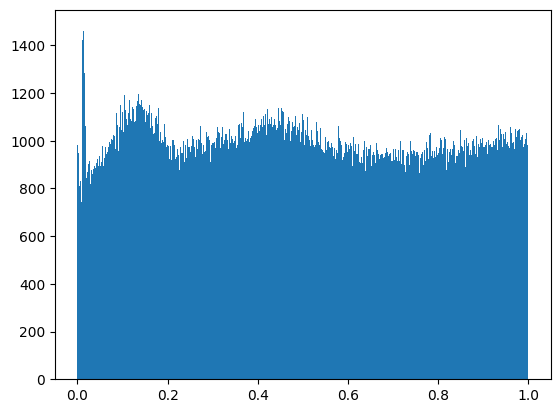

In [89]:
plt.hist(pvalues, bins=1000)
plt.show()